# Customer Support Operations Analytics

## Project Objective

This project analyzes 100,000 synthetic customer support tickets to evaluate support workload, resolution efficiency, backlog, reopen rates, SLA performance, and customer outcomes using Python, SQL, and PostgreSQL.

### Key Objectives

- Analyze customer support workload and ticket trends
- Measure resolution and backlog performance
- Compare operational performance across priorities, channels, products, and issue types
- Identify resolution-time and backlog hotspots
- Analyze reopen rates and customer satisfaction
- Derive actionable operational insights using SQL and Python

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Dataset Overview

The dataset contains 100,000 synthetic IT support tickets representing customer-support interactions across multiple channels, product areas, priorities, SLA plans, and customer segments.

### Dataset Dimensions

- **Rows:** 100,000
- **Columns:** 20
- **Time period:** 2022–2025
- **Source:** Kaggle — Synthetic IT Support Tickets
- **Data type:** Synthetic customer-support data

The dataset includes ticket metadata, customer and product information, support status, resolution details, customer sentiment, CSAT scores, and operational attributes.

In [2]:
file_path = "../data/raw/synthetic_it_support_tickets.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.shape

(100000, 20)

In [4]:
df.columns

Index(['ticket_id', 'created_at', 'customer_id', 'customer_segment', 'channel',
       'product_area', 'issue_type', 'priority', 'status', 'sla_plan',
       'initial_message', 'agent_first_reply', 'resolution_summary',
       'resolution_time_hours', 'reopened', 'customer_sentiment', 'csat_score',
       'has_attachment', 'platform', 'region'],
      dtype='object')

## 2. Data Loading and Initial Inspection

The raw dataset is loaded using Pandas and inspected to understand its structure, data types, missing values, and categorical distributions before performing cleaning and feature engineering.

In [5]:
df.head()

,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,initial_message,agent_first_reply,resolution_summary,resolution_time_hours,reopened,customer_sentiment,csat_score,has_attachment,platform,region
0,TCKT_000001,2024-01-31T05:14:27,CUST_00861,individual,email,data_export,account_access,low,resolved,standard,I cannot log in; the system says my password i...,Sorry to hear you're having trouble accessing ...,Reset account credentials and confirmed succes...,36.53,0,very_negative,1,0,android,EU
1,TCKT_000002,2024-10-20T06:15:49,CUST_00770,individual,in_app,billing,security_concern,medium,closed_no_action,standard,I noticed a suspicious login on my account.,We take security very seriously. Our team is r...,Ticket closed without further action after no ...,238.32,0,neutral,3,0,web,NaN
2,TCKT_000003,2024-06-18T21:35:54,CUST_02559,small_business,chat,api_integration,bug,low,in_progress,standard,The api integration feature is not saving my c...,Thanks for reporting this bug. We will look in...,NaN,NaN,0,neutral,3,0,android,MEA
3,TCKT_000004,2025-12-25T15:59:52,CUST_03557,education,chat,analytics_dashboard,account_access,medium,in_progress,standard,I cannot log in; the system says my password i...,Sorry to hear you're having trouble accessing ...,NaN,NaN,0,positive,5,1,android,LATAM
4,TCKT_000005,2023-08-27T16:08:33,CUST_09556,enterprise,phone_transcript,login_auth,billing_problem,low,resolved,gold,My invoice amount is incorrect compared to the...,Thanks for reaching out about the billing issu...,Adjusted the invoice and issued a refund where...,61.32,0,very_negative,2,0,web,NaN


## 3. Data Quality Assessment

Before analysis, the dataset was audited for missing values, duplicate records, invalid timestamps, inconsistent categorical values, and unexpected numerical values.

### Key Data Quality Findings

- No duplicate `ticket_id` values were found.
- All 100,000 ticket IDs are unique.
- All `created_at` values were successfully converted to datetime.
- `resolution_summary` and `resolution_time_hours` are missing for unresolved tickets.
- Missing resolution time was treated as structurally missing rather than imputed.
- Missing `region` values were represented as `Unknown`.
- Binary fields such as `reopened` and `has_attachment` contain valid 0/1 values.
- Categorical fields were checked for unexpected or inconsistent values.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ticket_id              100000 non-null  object 
 1   created_at             100000 non-null  object 
 2   customer_id            100000 non-null  object 
 3   customer_segment       100000 non-null  object 
 4   channel                100000 non-null  object 
 5   product_area           100000 non-null  object 
 6   issue_type             100000 non-null  object 
 7   priority               100000 non-null  object 
 8   status                 100000 non-null  object 
 9   sla_plan               100000 non-null  object 
 10  initial_message        100000 non-null  object 
 11  agent_first_reply      100000 non-null  object 
 12  resolution_summary     60113 non-null   object 
 13  resolution_time_hours  60113 non-null   float64
 14  reopened               100000 non-nul

In [7]:
df.isnull().sum()

ticket_id                    0
created_at                   0
customer_id                  0
customer_segment             0
channel                      0
product_area                 0
issue_type                   0
priority                     0
status                       0
sla_plan                     0
initial_message              0
agent_first_reply            0
resolution_summary       39887
resolution_time_hours    39887
reopened                     0
customer_sentiment           0
csat_score                   0
has_attachment               0
platform                     0
region                   19997
dtype: int64

In [8]:
pd.crosstab(
    df["status"],
    df["resolution_time_hours"].isna()
)

resolution_time_hours,False,True
status,,
closed_no_action,9982,0
in_progress,0,19783
on_hold,0,10165
open,0,9939
resolved,50131,0


In [9]:
pd.crosstab(
    df["status"],
    df["region"].isna()
)

region,False,True
status,,
closed_no_action,8013,1969
in_progress,15775,4008
on_hold,8129,2036
open,7982,1957
resolved,40104,10027


In [10]:
df["region"].value_counts(dropna=False)

region
MEA      20151
NaN      19997
EU       19960
LATAM    19959
APAC     19933
Name: count, dtype: int64

In [11]:
df["ticket_id"].duplicated().sum()

np.int64(0)

In [12]:
df["ticket_id"].nunique()

100000

In [13]:
df["created_at"].head()

0    2024-01-31T05:14:27
1    2024-10-20T06:15:49
2    2024-06-18T21:35:54
3    2025-12-25T15:59:52
4    2023-08-27T16:08:33
Name: created_at, dtype: object

In [14]:
pd.to_datetime(df["created_at"], errors="coerce").isna().sum()

np.int64(0)

In [15]:
df["created_at"] = pd.to_datetime(df["created_at"])

In [16]:
df["created_at"].dtype

dtype('<M8[ns]')

In [17]:
df["resolution_time_hours"].describe()

count    60113.000000
mean        45.013123
std         49.202797
min          0.110000
25%         14.880000
50%         29.910000
75%         51.660000
max        239.960000
Name: resolution_time_hours, dtype: float64

In [18]:
df["csat_score"].describe()

count    100000.000000
mean          2.241950
std           1.771599
min           0.000000
25%           0.000000
50%           2.000000
75%           4.000000
max           5.000000
Name: csat_score, dtype: float64

In [19]:
df["status"].value_counts()

status
resolved            50131
in_progress         19783
on_hold             10165
closed_no_action     9982
open                 9939
Name: count, dtype: int64

In [20]:
df["priority"].value_counts()

priority
low       39735
medium    35313
high      19865
urgent     5087
Name: count, dtype: int64

In [21]:
df["channel"].value_counts()

channel
phone_transcript    20133
email               20088
in_app              19982
web_form            19965
chat                19832
Name: count, dtype: int64

In [22]:
df["customer_segment"].value_counts()

customer_segment
small_business    20203
individual        20033
enterprise        20030
education         19958
non_profit        19776
Name: count, dtype: int64

In [23]:
df["product_area"].value_counts()

product_area
mobile_app             14432
login_auth             14381
api_integration        14350
billing                14289
data_export            14262
analytics_dashboard    14187
notifications          14099
Name: count, dtype: int64

In [24]:
df["issue_type"].value_counts()

issue_type
how_to              12739
account_access      12609
performance         12513
feature_request     12487
other               12463
security_concern    12458
billing_problem     12382
bug                 12349
Name: count, dtype: int64

In [25]:
df["customer_sentiment"].value_counts()

customer_sentiment
neutral          32634
negative         26015
very_negative    16437
positive         16242
very_positive     8672
Name: count, dtype: int64

In [26]:
df["platform"].value_counts()

platform
api_client     20095
web            20025
desktop_app    20015
ios            20009
android        19856
Name: count, dtype: int64

In [27]:
df["sla_plan"].value_counts()

sla_plan
standard    60066
gold        29875
platinum    10059
Name: count, dtype: int64

In [28]:
print("reopened:", df["reopened"].unique())
print("has_attachment:", df["has_attachment"].unique())

reopened: [0 1]
has_attachment: [0 1]


### Data Cleaning

The cleaning process preserves the original ticket information while preparing the data for operational analysis. Missing values are handled according to their meaning rather than being replaced indiscriminately.

In [29]:
df["region"] = df["region"].fillna("Unknown")

print(df["region"].value_counts())

region
MEA        20151
Unknown    19997
EU         19960
LATAM      19959
APAC       19933
Name: count, dtype: int64


In [30]:
categorical_cols = [
    "customer_segment",
    "channel",
    "product_area",
    "issue_type",
    "priority",
    "status",
    "sla_plan",
    "customer_sentiment",
    "platform"
]

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())


customer_segment:
['individual' 'small_business' 'education' 'enterprise' 'non_profit']

channel:
['email' 'in_app' 'chat' 'phone_transcript' 'web_form']

product_area:
['data_export' 'billing' 'api_integration' 'analytics_dashboard'
 'login_auth' 'mobile_app' 'notifications']

issue_type:
['account_access' 'security_concern' 'bug' 'billing_problem' 'performance'
 'feature_request' 'how_to' 'other']

priority:
['low' 'medium' 'urgent' 'high']

status:
['resolved' 'closed_no_action' 'in_progress' 'on_hold' 'open']

sla_plan:
['standard' 'gold' 'platinum']

customer_sentiment:
['very_negative' 'neutral' 'positive' 'negative' 'very_positive']

platform:
['android' 'web' 'ios' 'api_client' 'desktop_app']


## 4. Feature Engineering

Additional analytical features were created to support operational and time-based analysis.

### Time-Based Features

- `year`
- `month`
- `quarter`
- `day_of_week`
- `hour`

These features allow support workload to be analyzed across different time periods.

### Operational Features

- `is_resolved` — identifies resolved and closed tickets
- `is_backlog` — identifies open, in-progress, and on-hold tickets
- `resolution_time_band` — groups resolution time into operational time ranges

The engineered features are used throughout the SQL and Python analysis.

In [31]:
df["year"] = df["created_at"].dt.year
df["month"] = df["created_at"].dt.month
df["quarter"] = df["created_at"].dt.quarter
df["day_of_week"] = df["created_at"].dt.day_name()
df["hour"] = df["created_at"].dt.hour

df[["created_at", "year", "month", "quarter", "day_of_week", "hour"]].head()

,created_at,year,month,quarter,day_of_week,hour
0,2024-01-31 05:14:27,2024,1,1,Wednesday,5
1,2024-10-20 06:15:49,2024,10,4,Sunday,6
2,2024-06-18 21:35:54,2024,6,2,Tuesday,21
3,2025-12-25 15:59:52,2025,12,4,Thursday,15
4,2023-08-27 16:08:33,2023,8,3,Sunday,16


In [32]:
df["is_resolved"] = df["status"].isin(
    ["resolved", "closed_no_action"]
).astype(int)

print(df["is_resolved"].value_counts())

is_resolved
1    60113
0    39887
Name: count, dtype: int64


In [33]:
df["is_backlog"] = df["status"].isin(
    ["open", "in_progress", "on_hold"]
).astype(int)

print(df["is_backlog"].value_counts())

is_backlog
0    60113
1    39887
Name: count, dtype: int64


### Resolution Time Classification

Resolved tickets were grouped into operational resolution-time bands:

- Under 1 day
- 1–2 days
- 2–3 days
- Over 3 days

Tickets without a resolution time remain unclassified because they represent unresolved support work.

In [34]:
bins = [-np.inf, 24, 48, 72, np.inf]
labels = ["Under 1 day", "1–2 days", "2–3 days", "Over 3 days"]

df["resolution_time_band"] = pd.cut(
    df["resolution_time_hours"],
    bins=bins,
    labels=labels,
    right=False
)

print(df["resolution_time_band"].value_counts(dropna=False))

resolution_time_band
NaN            39887
Under 1 day    25628
1–2 days       18129
2–3 days        8628
Over 3 days     7728
Name: count, dtype: int64


In [35]:
cleaned_path = "../data/cleaned/customer_support_cleaned.csv"
df.to_csv(cleaned_path, index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## 5. Exploratory Data Analysis

Exploratory analysis was performed to understand support workload patterns, resolution efficiency, backlog composition, resolution quality, and customer outcomes.

The analysis focuses on operational questions rather than generating visualizations for every available field.

### 5.1 Monthly Ticket Volume

This analysis examines how customer-support workload changes over time across the 2022–2025 period.

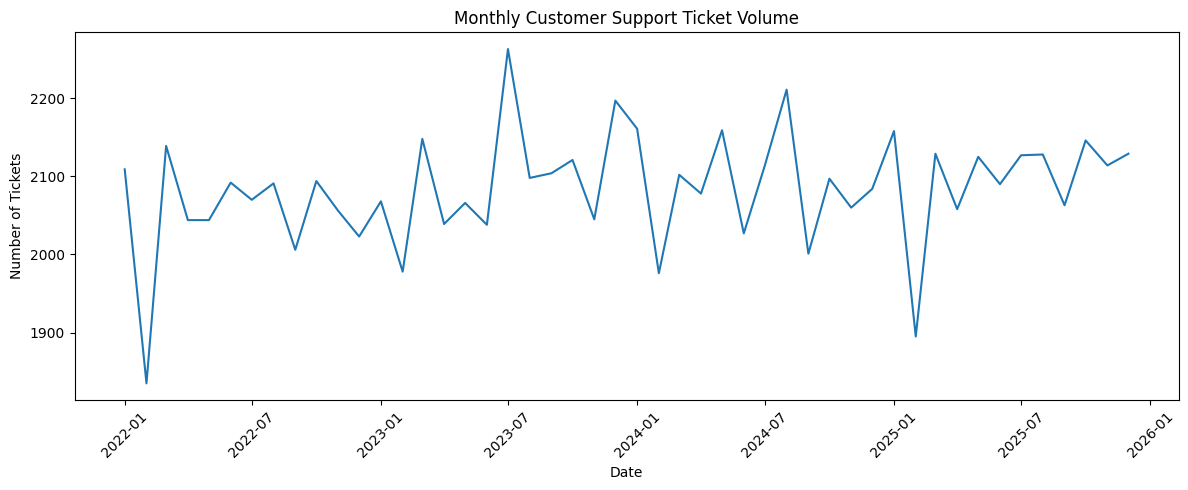

In [36]:
monthly_tickets = (
    df.groupby(["year", "month"])
      .size()
      .reset_index(name="total_tickets")
)

monthly_tickets["date"] = pd.to_datetime(
    monthly_tickets["year"].astype(str) + "-" +
    monthly_tickets["month"].astype(str) + "-01"
)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_tickets["date"],
    monthly_tickets["total_tickets"]
)

plt.title("Monthly Customer Support Ticket Volume")
plt.xlabel("Date")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../visualizations/monthly_ticket_volume.png", dpi=300, bbox_inches="tight")
plt.show()


### 5.2 Resolution Time by Priority

This analysis compares average resolution time across ticket priority levels to identify differences in resolution efficiency.

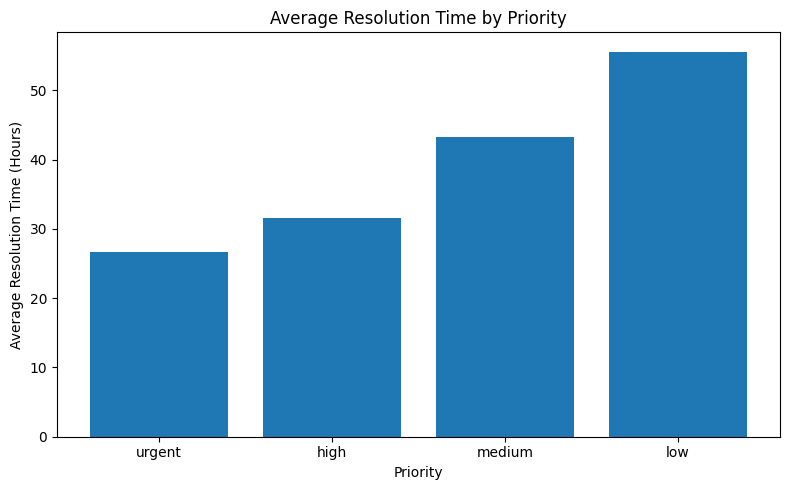

In [37]:
priority_resolution = (
    df.groupby("priority")["resolution_time_hours"]
      .mean()
      .reindex(["urgent", "high", "medium", "low"])
)

plt.figure(figsize=(8, 5))

plt.bar(
    priority_resolution.index,
    priority_resolution.values
)

plt.title("Average Resolution Time by Priority")
plt.xlabel("Priority")
plt.ylabel("Average Resolution Time (Hours)")
plt.tight_layout()
plt.savefig("../visualizations/resolution_time_by_priority.png", dpi=300, bbox_inches="tight")
plt.show()

### 5.3 Reopen Rate by Issue Type

This analysis compares ticket reopen rates across issue types as an indicator of resolution quality.

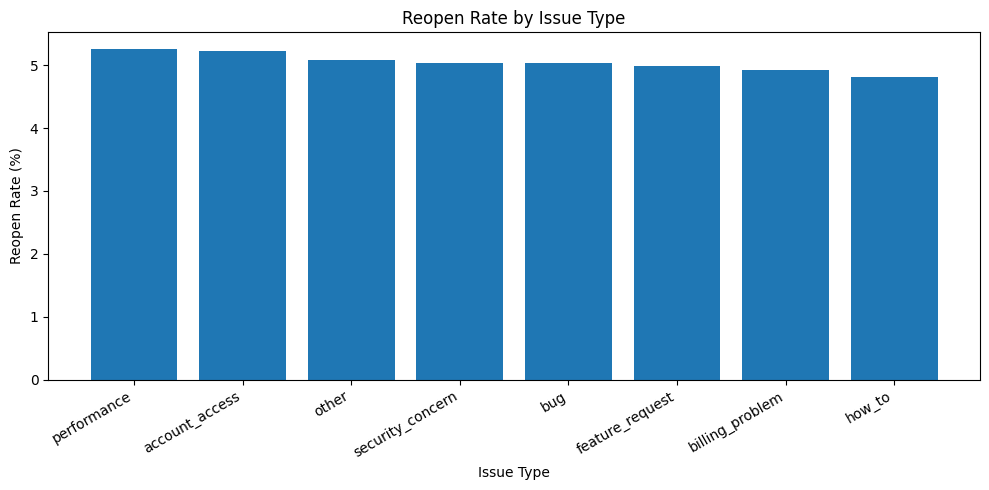

In [38]:
issue_reopen = (
    df.groupby("issue_type")["reopened"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

plt.bar(
    issue_reopen.index,
    issue_reopen.values
)

plt.title("Reopen Rate by Issue Type")
plt.xlabel("Issue Type")
plt.ylabel("Reopen Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../visualizations/reopen_rate_by_issue_type.png", dpi=300, bbox_inches="tight")
plt.show()

### 5.4 Customer Satisfaction by Issue Type

This analysis examines differences in average CSAT across issue categories and provides a secondary view of customer outcomes.

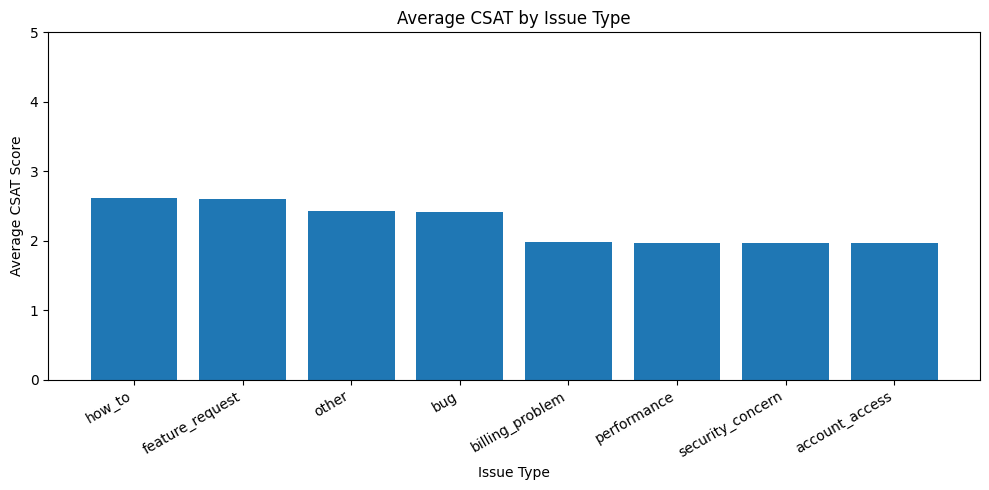

In [39]:
issue_csat = (
    df.groupby("issue_type")["csat_score"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

plt.bar(
    issue_csat.index,
    issue_csat.values
)

plt.title("Average CSAT by Issue Type")
plt.xlabel("Issue Type")
plt.ylabel("Average CSAT Score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 5)

plt.tight_layout()
plt.savefig("../visualizations/average_csat_by_issue_type.png", dpi=300, bbox_inches="tight")
plt.show()

### 5.5 Backlog Composition

This analysis examines the composition of unresolved support workload across open, in-progress, and on-hold tickets.

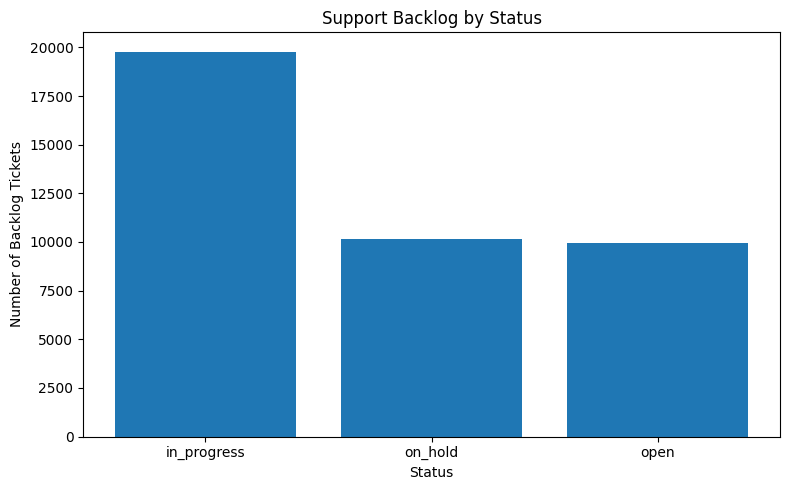

In [40]:
backlog_status = (
    df[df["is_backlog"] == 1]
    .groupby("status")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    backlog_status.index,
    backlog_status.values
)

plt.title("Support Backlog by Status")
plt.xlabel("Status")
plt.ylabel("Number of Backlog Tickets")

plt.tight_layout()
plt.savefig("../visualizations/backlog_by_status.png", dpi=300, bbox_inches="tight")
plt.show()

### 5.6 Resolution Time by Priority and Issue Type

This analysis combines priority and issue type to identify resolution-time patterns that may not be visible when analyzing either dimension independently.

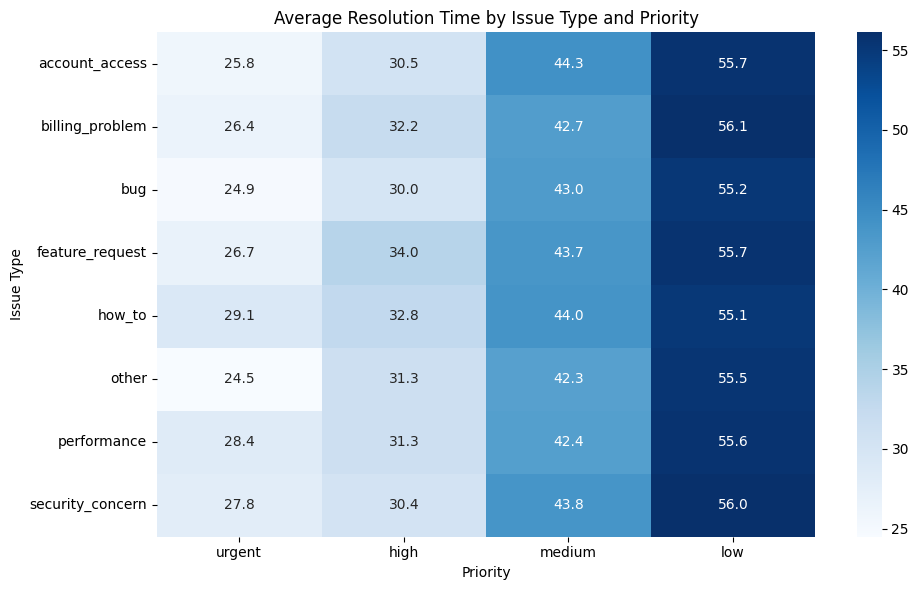

In [41]:
priority_order = ["urgent", "high", "medium", "low"]

resolution_heatmap = (
    df.pivot_table(
        values="resolution_time_hours",
        index="issue_type",
        columns="priority",
        aggfunc="mean"
    )
    .reindex(columns=priority_order)
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    resolution_heatmap,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Average Resolution Time by Issue Type and Priority")
plt.xlabel("Priority")
plt.ylabel("Issue Type")

plt.tight_layout()
plt.savefig("../visualizations/resolution_time_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### 5.7 Backlog Rate by Product Area and Issue Type

This analysis identifies product-area and issue-type combinations with relatively higher proportions of unresolved tickets.

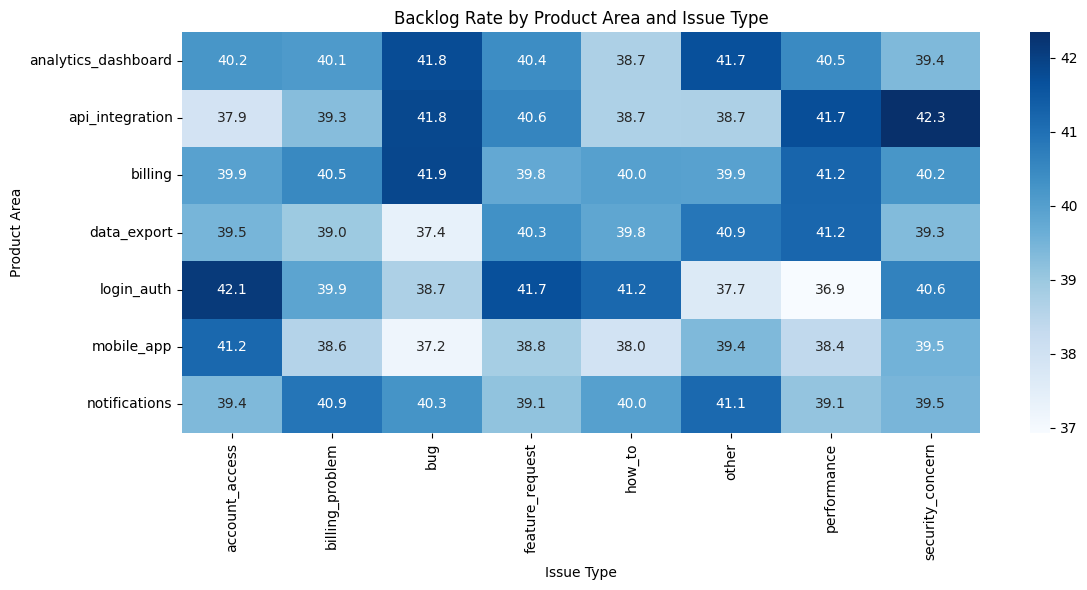

In [42]:
backlog_heatmap = (
    df.pivot_table(
        values="is_backlog",
        index="product_area",
        columns="issue_type",
        aggfunc="mean"
    ) * 100
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    backlog_heatmap,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Backlog Rate by Product Area and Issue Type")
plt.xlabel("Issue Type")
plt.ylabel("Product Area")

plt.tight_layout()
plt.savefig("../visualizations/backlog_rate_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [43]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Tickets",
        "Resolved Tickets",
        "Backlog Tickets",
        "Resolution Rate (%)",
        "Reopen Rate (%)",
        "Average Resolution Time (Hours)",
        "Average CSAT"
    ],
    "Value": [
        len(df),
        df["is_resolved"].sum(),
        df["is_backlog"].sum(),
        df["is_resolved"].mean() * 100,
        df["reopened"].mean() * 100,
        df["resolution_time_hours"].mean(),
        df["csat_score"].mean()
    ]
})

kpi_summary["Value"] = kpi_summary["Value"].round(2)

kpi_summary

,Metric,Value
0,Total Tickets,100000.00
1,Resolved Tickets,60113.00
2,Backlog Tickets,39887.00
3,Resolution Rate (%),60.11
4,Reopen Rate (%),5.04
5,Average Resolution Time (Hours),45.01
6,Average CSAT,2.24


## 6. Key Findings & Recommendations

### Key Findings

1. **Support workload remained relatively stable**
   - Monthly ticket volume stayed broadly within the 1,800–2,200 range across 2022–2025.
   - No sustained increase or decrease in overall ticket volume was observed.

2. **Priority has a strong relationship with resolution time**
   - Urgent tickets averaged approximately 26.7 hours to resolve.
   - Low-priority tickets averaged approximately 55.6 hours.
   - Resolution rates remained close to 60% across priority levels.

3. **Customer satisfaction varies more across issue types than resolution time**
   - `how_to` and `feature_request` tickets had the highest average CSAT.
   - `account_access`, `performance`, and `security_concern` had lower average CSAT.
   - Average resolution times across issue types were relatively similar.

4. **The unresolved workload is concentrated in in-progress tickets**
   - There were 39,887 backlog tickets.
   - Approximately half of the backlog was in `in_progress` status.
   - `on_hold` and `open` tickets made up the remainder.

5. **Product-area and issue-type combinations reveal backlog hotspots**
   - Several product–issue combinations had backlog rates above 40%.
   - This indicates that operational bottlenecks can be more visible when product area and issue type are analyzed together.

6. **Resolution bottlenecks differ by priority**
   - The slowest issue type was not the same across all priority levels.
   - This supports analyzing priority and issue type jointly rather than relying only on overall averages.

7. **Reopen rates showed relatively small differences**
   - Reopen rates across issue types remained within a relatively narrow range of approximately 4.8%–5.3%.
   - Therefore, reopen rate alone does not explain most of the operational variation in this dataset.

### Recommendations

- Review backlog at the **product-area × issue-type** level to identify recurring operational bottlenecks.
- Investigate lower-CSAT issue categories such as account access, performance, and security-related tickets, including resolution communication and root-cause handling.
- Use the **priority × issue-type** analysis to support workload routing and operational planning.
- Monitor the large `in_progress` backlog segment and review queue-management processes.
- Use historical monthly ticket volumes as a baseline for support capacity planning.
- Continue tracking reopen rate, but evaluate it alongside resolution time, backlog, and CSAT rather than using it as a standalone KPI.

## 7. Conclusion

This project analyzed 100,000 synthetic customer support tickets using Python, PostgreSQL, and SQL to evaluate support workload, resolution efficiency, backlog, reopen rates, SLA performance, and customer satisfaction.

The analysis showed that overall support workload remained relatively stable over the observed period, while resolution time varied substantially by ticket priority. Customer satisfaction showed noticeable differences across issue types, and combining product area with issue type revealed specific backlog hotspots that were less visible in high-level analysis.

The project demonstrates an end-to-end analytics workflow covering data cleaning, feature engineering, PostgreSQL data loading, SQL analysis, exploratory data analysis, KPI development, visualization, and business-oriented interpretation.

The resulting analysis can support operational teams in identifying workload patterns, investigating bottlenecks, and prioritizing areas for further process improvement.